Event ID               0
Timestamp              0
Source IP              0
Destination IP         0
User Agent             0
Attack Type            0
Attack Severity        0
Data Exfiltrated       0
Threat Intelligence    0
Response Action        0
dtype: int64
                                    Event ID            Timestamp  \
count                                  20000                20000   
unique                                 20000                19997   
top     23f07a51-1bad-4015-a54c-d1871060726e  2022-05-22 01:25:51   
freq                                       1                    2   

            Source IP Destination IP  \
count           20000          20000   
unique          20000          20000   
top     150.31.102.31  131.62.18.169   
freq                1              1   

                                               User Agent Attack Type  \
count                                               20000       20000   
unique                                      

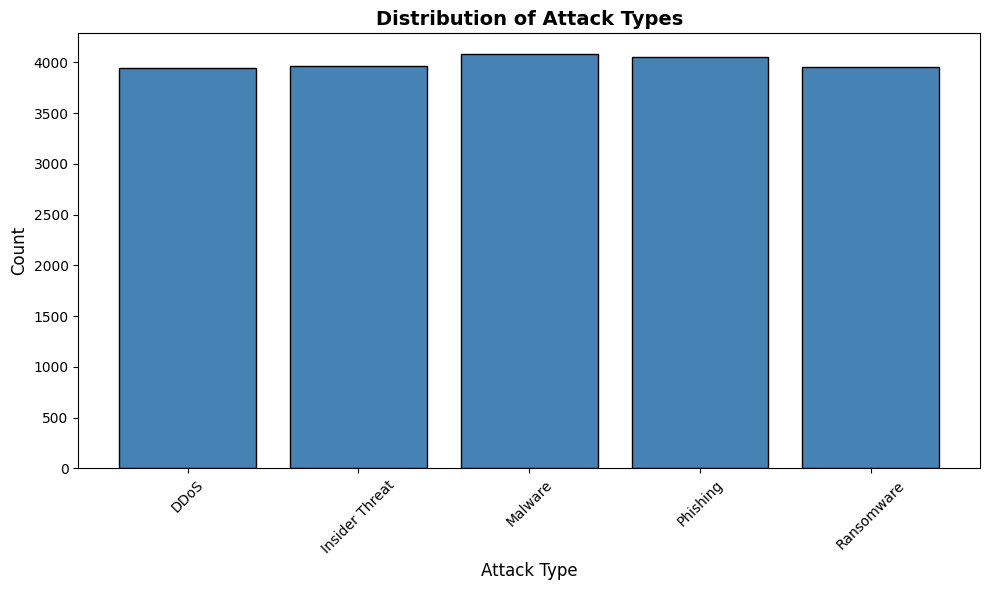

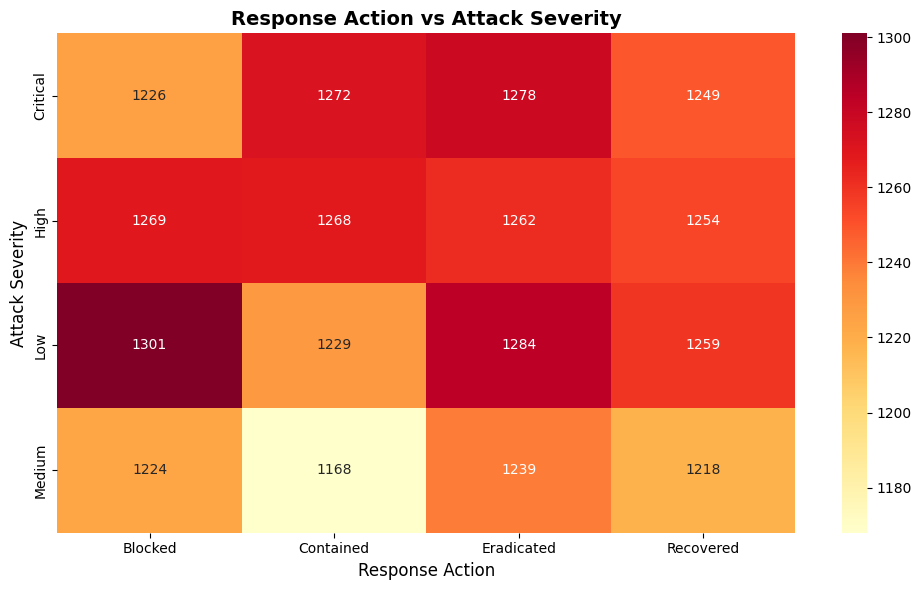

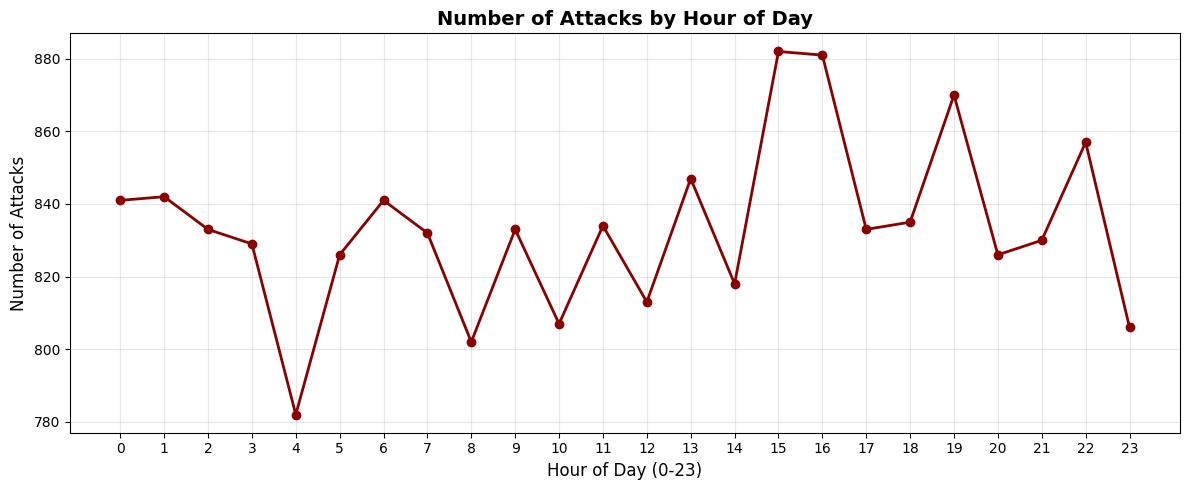

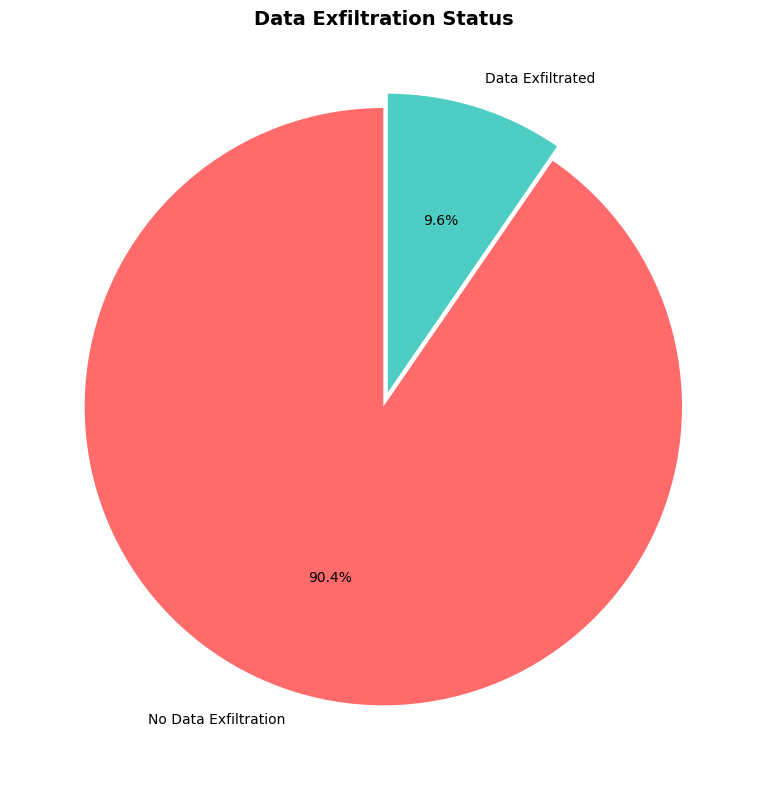

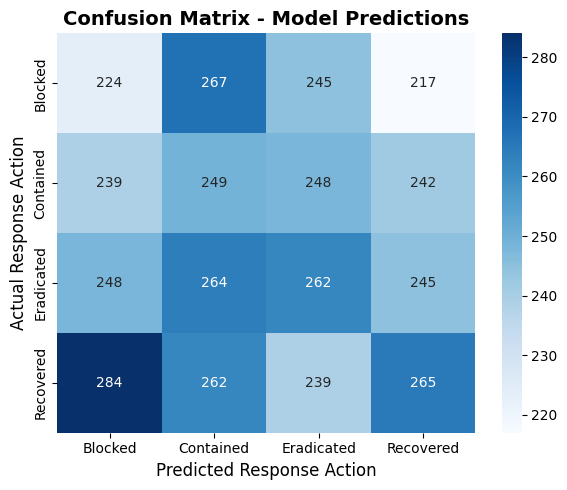


 Model Accuracy: 0.2500


In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("ai_ml_cybersecurity_dataset.csv")
"""print(df)"""

"""Cleaning (no null values in data)"""
print(df.isnull().sum())
print(df.describe())
print(df.head())

drop_cols = [
    'Event ID',
    'Source IP',
    'Destination IP',
    'User Agent',
    'Threat Intelligence'
]

df.drop(columns=drop_cols, inplace=True)

'''Encoding'''
le_attack = LabelEncoder()
le_severity = LabelEncoder()
le_response = LabelEncoder()

df['Attack Type'] = le_attack.fit_transform(df['Attack Type'])
df['Attack Severity'] = le_severity.fit_transform(df['Attack Severity'])
df['Response Action'] = le_response.fit_transform(df['Response Action'])

print(df['Attack Severity'],df['Attack Type'],df['Response Action'])

df['Data Exfiltrated']=df['Data Exfiltrated'].astype(int)
print(df['Data Exfiltrated'])
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month

df.drop('Timestamp', axis=1, inplace=True)

# ============ PLOT 1: Attack Type Distribution ============
plt.figure(figsize=(10, 6))
attack_counts = df['Attack Type'].value_counts().sort_index()
plt.bar(le_attack.classes_, attack_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Attack Types', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('attack_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ PLOT 2: Response Action by Attack Severity (Heatmap) ============
severity_names = le_severity.classes_
response_names = le_response.classes_

# Create cross-tabulation
cross_tab = pd.crosstab(df['Attack Severity'], df['Response Action'])

plt.figure(figsize=(10, 6))
print('\n')
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=response_names, yticklabels=severity_names)
plt.title('Response Action vs Attack Severity', fontsize=14, fontweight='bold')
plt.xlabel('Response Action', fontsize=12)
plt.ylabel('Attack Severity', fontsize=12)
plt.tight_layout()
plt.savefig('severity_response_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ PLOT 3: Attacks by Hour of Day ============
plt.figure(figsize=(12, 5))
hourly_attacks = df.groupby('Hour').size()
print('\n')
plt.plot(hourly_attacks.index, hourly_attacks.values, marker='o', color='darkred', linewidth=2)
plt.title('Number of Attacks by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('attacks_by_hour.png', dpi=300, bbox_inches='tight')
plt.show()

# ============ PLOT 4: Data Exfiltrated Pie Chart ============
plt.figure(figsize=(8, 8))
exfil_counts = df['Data Exfiltrated'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
labels = ['No Data Exfiltration', 'Data Exfiltrated']
print('\n')
plt.pie(exfil_counts.values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0, 0.05))
plt.title('Data Exfiltration Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data_exfiltration.png', dpi=300, bbox_inches='tight')
plt.show()


'''Model Building'''

X=df.drop('Response Action',axis=1)
y=df['Response Action']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train_scaled,y_train)

y_pred=model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
# Get the original class names for the response action
response_names = le_response.classes_
print('\n')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=response_names, yticklabels=response_names)
plt.title('Confusion Matrix - Model Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Response Action', fontsize=12)
plt.ylabel('Actual Response Action', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print accuracy
print(f"\n Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")